In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


# 1. Imports

In [2]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

In [3]:
train = pd.read_csv("../tf_env/testdata/trainCNN.csv")
test = pd.read_csv("../tf_env/testdata/testCNN.csv")

In [4]:
# separating labels from pixel values
Y = train["label"]

# rest of columns are pixel values
X = train.drop(columns = ["label"])

In [5]:
#converting dataframe/series to numpy arrays

X = X.values
Y = Y.values

test = test.values

In [6]:
#normalization of the data
# original pixel values are from 0 to 255
# neural networks train better when values are between 0 and 1

X = X.astype("float32") / 255.0

test = test.astype("float32") / 255.0

In [7]:
# so here we are reshaping each data for a CNN input
# before reshaping, it provides 
X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

# training data so data 
print("Training data shape: ", X.shape)
print("Test data shape: ", test.shape)

Training data shape:  (42000, 28, 28, 1)
Test data shape:  (28000, 28, 28, 1)


In [8]:
# splitting the training data into training and validation sets
# validation  est lets us check perofrmance on data the model didn't train on

X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y, 
    test_size = 0.1,
    random_state = 42,
    stratify = Y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("Y_train shape:", Y_train.shape)
print("Y_val shape:", Y_val.shape)

X_train shape: (37800, 28, 28, 1)
X_val shape: (4200, 28, 28, 1)
Y_train shape: (37800,)
Y_val shape: (4200,)


# 2. Data Augmentation
Makes slightly changed copies of training images so the model gets to know more variety while learning.

Only changes the images during training

In [9]:
# data augmentation uses modified images during training
# helps the model generalize better


data_augmentation = keras.Sequential([
    # randomly rotates the image a bit 
    # 0.08 means 8% of a full circle
    # 
    layers.RandomRotation(0.08),

    # zooms in image in or out by 10%
    # helps because some digits can be larger or smaller
    layers.RandomZoom(0.10),

    # shifting image up or down, 
    # height and width will move up or down by 10%
    layers.RandomTranslation(height_factor = 0.10, width_factor = 0.10),

    # basically the idea is that even if the image is shfited, 
    # CNN will know it is still a 7
])

# 3. Building the CNN Model

basically it does this...

takes an image, runs data augmentation, finds patterns with convolution block, shrinks it, find bigger patterns, flattens it out, and classifies the digit in the end.

note: the dimensions of each image are 28x28, and the third value are filters.

We use 32 filters, so after the convolution block, the original 1 channel turns into 32. examples could be:
- edge detector map
- curve detector map
- corner detector map
- line detector map

**Convolution block:** takes in the image, creates a small section of the image, and learns filters that detect patterns in those sections

Code scans 5x5 windows in first convolution block, 
- filters = 32 means model learns 32 different pattern detectors
- padding = "same" means output is kept at the same height and width
- activation = "relu" keeps positive signals and turns negative ones into 0
    - helps model learn better

**MaxPooling2D**:
- Shrinks feature of maps from each 2x2 area
- Ex. 28x28x32 --> 14x14x32

**layers.Dropout(0.25)** randomly turns off 25% of neurons during training
- prevents overfitting

**Second Convolution Block**: used to learn more complex patters, filters is double to 64, maxpooling cuts down size to 7x7x64

**layers.Flatten()**: used to turn into one 1D list because Dense layers require this input
- 7*7*64 = 3136 inputs

**layers.Dense()**: connects full layer and starts making classification decision
- Asks the question, "Given these detected features, which digit is this most likely to be?"
- "softmax" turns outputs into probabilities
    - ex: [0.01, 0.02, 0.00, 0.04, 0.01, 0.03, 0.00, 0.85, 0.02, 0.02]
    - model will think its 7 because probability at index 7 is highest

In [10]:
model = keras.Sequential([
    # input layer to tell the model the shape of an image sample
    layers.Input(shape = (28, 28, 1)),

    # applying data augmentation
    data_augmentation,

    # convolution block
    layers.Conv2D(filters = 32, kernel_size = (5, 5), padding = "same", activation = "relu"),
    layers.Conv2D(filters = 32, kernel_size = (5, 5), padding = "same", activation = "relu"),
    
    # MaxPooling reduces image size while keepign important features
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # second convolution block but it learns more complex patterns than first
    layers.Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation = "relu"),
    layers.Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation = "relu"),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.25),

    #flattening: converts 2D features into a 1D vector
    # Dense layers need 1D inputs
    layers.Flatten(),

    layers.Dense(256, activation = "relu"),
    layers.Dropout(0.5), 

    layers.Dense(10, activation = "softmax")
])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,530 (3.39 MB)

 Trainable params: 887,530 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Compiling the Model

optimizer (RMSprop): controls how the model learns from its mistakes

model predicts digit --> model checks how wrong it was --> optimizer adjusts the model --> model hopefully improves

learning rate = 0.001
- large learning rate = learns faster, but may overshoot
- small learning rate = learns slower, but more carefully

rho = 0.9: controls how much RMSprop remembers recent gradient behavior

epsilon = 1e-08: number added to prevent division errors


In [12]:
optimizer = keras.optimizers.RMSprop(
    learning_rate = 0.001, 
    rho = 0.9, 
    epsilon = 1e-08
)

prepares model for training

1. optimizer = optimizer is how it updates itself when it makes mistakes.
    - RMS prop is what adjusts the model's weights and reduces errors.

2. loss describes how wrong the model is

3. metrics tell Keras what score to show while training
    - number correct / total number of predictions
    - ex. accuracy = 95 images correct / 100 total images
        - 95%

In [13]:
model.compile(
    optimizer = optimizer,
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

# 5. Learning Rate Annealer/Callbacks
Callbacks are something in Keras that checks during training to decide whether to change something or stop training

In [14]:
# essentially means "if validation accuracy stops improving, lower the learning rate"
# if model gets stuck, smaller steps can help fine tune it

learning_rate_reduction = keras.callbacks.ReduceLROnPlateau(
    # watching validation accuracy
    monitor = "val_accuracy",

    #wait 3 epochs before reducing learning rate
    patience = 3, 

    # cut learning rate in half
    factor = 0.5, 

    # learning rate cannot go below this value
    min_lr = 1e-6,

    # will print a message if the learning rate is lowered
    verbose = 1
)

In [15]:
# stopping training if validation accuracy doesn't improve

early_stopping = keras.callbacks.EarlyStopping(
    monitor = "val_accuracy",
    patience = 8,

    # goes back to the model weights from the best epochs if further epochs gets worse and worse
    restore_best_weights = True,
    verbose = 1
)

In [16]:
callbacks = [
    learning_rate_reduction,
    early_stopping
]

# Training the Model
What this code does step by step:
1. show the model the training images
2. compare predictions to correct labels
3. update the model
4. check performance on validation data
5. repeat

Use to check if the model is learning general patterns or just memorizing the training data.

In [ ]:
history = model.fit(
    X_train, 
    Y_train,

    #train 86 images at a time
    batch_size = 86, 
    epochs = 30, 

    # validation data is not used to update the weights
    # can separate data to test itself during training
    validation_data = (X_val, Y_val),
    callbacks = callbacks
)

Epoch 1/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.8279 - loss: 0.5315 - val_accuracy: 0.9748 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 2/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9450 - loss: 0.1804 - val_accuracy: 0.9819 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 3/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.9595 - loss: 0.1369 - val_accuracy: 0.9869 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 4/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.9671 - loss: 0.1091 - val_accuracy: 0.9886 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 5/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9712 - loss: 0.0971 - val_accuracy: 0.9914 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 6/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9730 - loss: 0.0901 - val_accuracy: 0.9910 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 7/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9755 - l

After training, it seemed like the val_loss got worse after epoch #7. 

# 7. Evaluate the Model

In [ ]:
val_loss, val_accuracy = model.evaluate(X_val, Y_val, verbose = 0)

print("Validation loss: ", val_loss)
print("Validation accuracy: ", val_accuracy)

Validation loss:  0.025003831833600998
Validation accuracy:  0.993571400642395


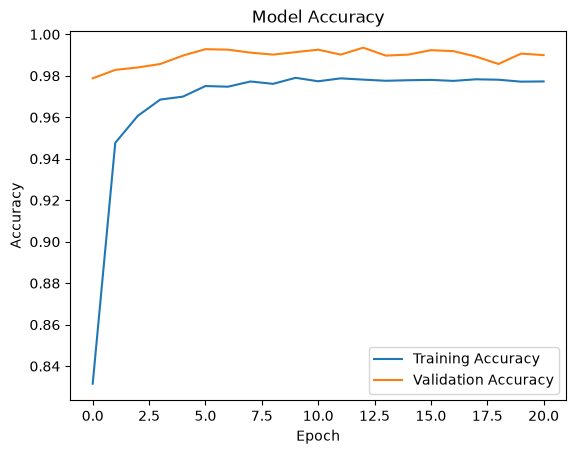

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 8. Confusion Matrix  


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


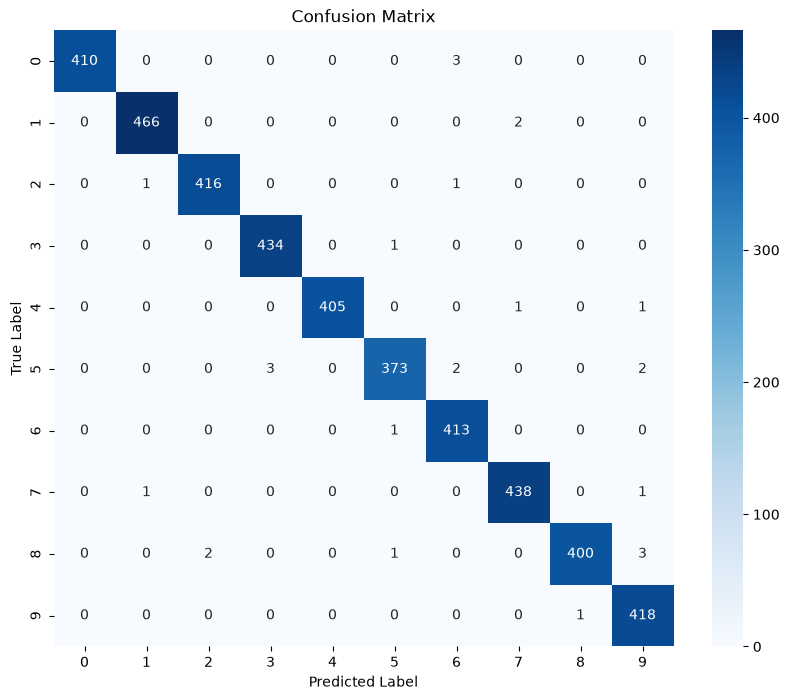

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predicted probabilities for the validation set
Y_val_pred_probs = model.predict(X_val)

# Convert probabilities into predicted digit labels
Y_val_pred = np.argmax(Y_val_pred_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(Y_val, Y_val_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Display Incorrect Predictions

In [ ]:
# Find indexes where the prediction was wrong
errors = np.where(Y_val_pred != Y_val)[0]

print("Number of errors:", len(errors))

Number of errors: 27


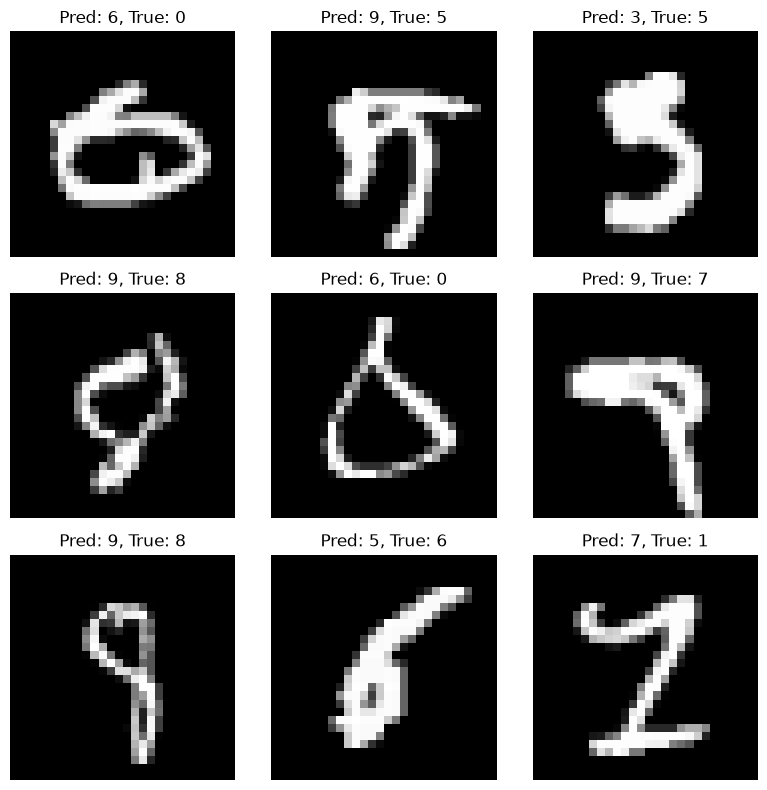

In [ ]:
# Show a few incorrect predictions
num_images = min(9, len(errors))

plt.figure(figsize=(8, 8))

for i in range(num_images):
    index = errors[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(X_val[index].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {Y_val_pred[index]}, True: {Y_val[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Overall summary in this notebook (NOTE: this data was before I ran another):
The model trained for 21 epochs, but it did not use all 30 because EarlyStopping stopped it early.

The most important line is:
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 13.

That means the best validation performance happened at epoch 13, so Keras restored the model back to that version.

At epoch 13, the model spitted out:

- accuracy: 0.9782
- loss: 0.0798
- val_accuracy: 0.9936
- val_loss: 0.0250
- learning_rate: 0.0010

So the best validation accuracy was:
- 0.9936 = 99.36%

Which is very good.

Also, I understand what each column means:
- accuracy = how well the model did on training data
- loss = how wrong it was on training data
- val_accuracy = how well it did on validation data
- val_loss = how wrong it was on validation data
- learning_rate = how big the model's learning steps were

Or basically in plain English:
- The model quickly learned the digit patterns.
- Validation accuracy improved until around epoch 13.
- After that, validation accuracy stopped improving consistently.
- EarlyStopping waited 8 more epochs, then stopped training.
- It restored the model back to epoch 13 because that was the best version.

One thing to notice: the training accuracy is around 97.8%, while validation accuracy is around 99.36%. That might look weird because validation is higher than training, but it can happen here because the training data uses data augmentation and dropout.

During training, the model sees harder versions of the images:
- rotated
- shifted
- zoomed
- randomly dropped neurons

But during validation, augmentation and dropout are not active, so validation can look cleaner/easier.

Also, the learning rate stayed at:

0.0010

the whole time. That means ReduceLROnPlateau probably did not visibly reduce it before early stopping finished, or the logs shown did not catch a reduced step.